In [196]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [197]:
df = pd.read_excel("../data/Telco_customer_churn.xlsx")  
df.shape

(7043, 33)

In [198]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   str    
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   str    
 3   State              7043 non-null   str    
 4   City               7043 non-null   str    
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   str    
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   str    
 10  Senior Citizen     7043 non-null   str    
 11  Partner            7043 non-null   str    
 12  Dependents         7043 non-null   str    
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   str    
 15  Multiple Lines     7043 non-null   str    
 16  Internet Service   7043 non-null   

In [199]:
df.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,No,No,Yes,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,No,No,Yes,49,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [200]:
df.tail()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
7038,2569-WGERO,1,United States,California,Landers,92285,"34.341737, -116.539416",34.341737,-116.539416,Female,No,No,No,72,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Bank transfer (automatic),21.15,1419.4,No,0,45,5306,NaN
7039,6840-RESVB,1,United States,California,Adelanto,92301,"34.667815, -117.536183",34.667815,-117.536183,Male,No,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No,0,59,2140,NaN
7040,2234-XADUH,1,United States,California,Amboy,92304,"34.559882, -115.637164",34.559882,-115.637164,Female,No,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No,0,71,5560,NaN
7041,4801-JZAZL,1,United States,California,Angelus Oaks,92305,"34.1678, -116.86433",34.167800,-116.864330,Female,No,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No,0,59,2793,NaN
7042,3186-AJIEK,1,United States,California,Apple Valley,92308,"34.424926, -117.184503",34.424926,-117.184503,Male,No,No,No,66,Yes,No,Fiber optic,Yes,No,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No,0,38,5097,NaN


In [201]:
# inspecting the state and country values 
print(df['State'].value_counts())
print(df['Country'].value_counts())


State
California    7043
Name: count, dtype: int64
Country
United States    7043
Name: count, dtype: int64


confirmed the state and country are the same across the whole dataset so completely useless

In [202]:
df.describe()

,Count,Zip Code,Latitude,Longitude,Tenure Months,Monthly Charges,Churn Value,Churn Score,CLTV
count,7043.0,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,1.0,93521.964646,36.282441,-119.798880,32.371149,64.761692,0.265370,58.699418,4400.295755
std,0.0,1865.794555,2.455723,2.157889,24.559481,30.090047,0.441561,21.525131,1183.057152
min,1.0,90001.000000,32.555828,-124.301372,0.000000,18.250000,0.000000,5.000000,2003.000000
25%,1.0,92102.000000,34.030915,-121.815412,9.000000,35.500000,0.000000,40.000000,3469.000000
50%,1.0,93552.000000,36.391777,-119.730885,29.000000,70.350000,0.000000,61.000000,4527.000000
75%,1.0,95351.000000,38.224869,-118.043237,55.000000,89.850000,1.000000,75.000000,5380.500000
max,1.0,96161.000000,41.962127,-114.192901,72.000000,118.750000,1.000000,100.000000,6500.000000


In [203]:
# also checking different values of count and city
print(df['Count'].value_counts())
print(df['City'].value_counts())

Count
1    7043
Name: count, dtype: int64
City
Los Angeles       305
San Diego         150
San Jose          112
Sacramento        108
San Francisco     104
                 ... 
Milford             4
Calpine             4
Standish            4
Tulelake            4
Olympic Valley      4
Name: count, Length: 1129, dtype: int64


The whole dataset is with count 1 but the city has different values but should check if there is any differences across the different cities.
Also note, lat long is 2 numbers seperated by a coma , and Total charges is a string while its orignally a float number 

In [204]:
print("Fully duplicated rows:", df.duplicated().sum())
print("Duplicate customerIDs:", df['CustomerID'].duplicated().sum())

Fully duplicated rows: 0
Duplicate customerIDs: 0


In [205]:
df.isnull().sum()

CustomerID              0
Count                   0
Country                 0
State                   0
City                    0
Zip Code                0
Lat Long                0
Latitude                0
Longitude               0
Gender                  0
Senior Citizen          0
Partner                 0
Dependents              0
Tenure Months           0
Phone Service           0
Multiple Lines          0
Internet Service        0
Online Security         0
Online Backup           0
Device Protection       0
Tech Support            0
Streaming TV            0
Streaming Movies        0
Contract                0
Paperless Billing       0
Payment Method          0
Monthly Charges         0
Total Charges           0
Churn Label             0
Churn Value             0
Churn Score             0
CLTV                    0
Churn Reason         5174
dtype: int64

findings : there is a big number of nulls in the churn reason column and even though its found as long text so will this be useful for the model? also no duplicate found and three columns have one value across the dataset

In [206]:
df['Total Charges'] = pd.to_numeric(df['Total Charges'], errors='coerce')
# errors='coerce' will convert non-numeric values to NaN if they cannot be converted to a number.
print("Missing TotalCharges after coercion:", df['Total Charges'].isnull().sum())
# df.loc[boolean_series, columns]
df.loc[df['Total Charges'].isnull(), ['CustomerID', 'Tenure Months', 'Monthly Charges', 'Total Charges']]

Missing TotalCharges after coercion: 11


,CustomerID,Tenure Months,Monthly Charges,Total Charges
2234,4472-LVYGI,0,52.55,NaN
2438,3115-CZMZD,0,20.25,NaN
2568,5709-LVOEQ,0,80.85,NaN
2667,4367-NUYAO,0,25.75,NaN
2856,1371-DWPAZ,0,56.05,NaN
4331,7644-OMVMY,0,19.85,NaN
4687,3213-VVOLG,0,25.35,NaN
5104,2520-SGTTA,0,20.00,NaN
5719,2923-ARZLG,0,19.70,NaN
6772,4075-WKNIU,0,73.35,NaN


In [207]:
# the total charges is NAN for customers with tenure of 0 months. We can fill the missing values with 0.
df['Total Charges'] = df['Total Charges'].fillna(0)
print("Missing Total Charges after filling:", df['Total Charges'].isnull().sum())

Missing Total Charges after filling: 0


churn data tend to be inbalanced so we need to check this and take a suitable action 

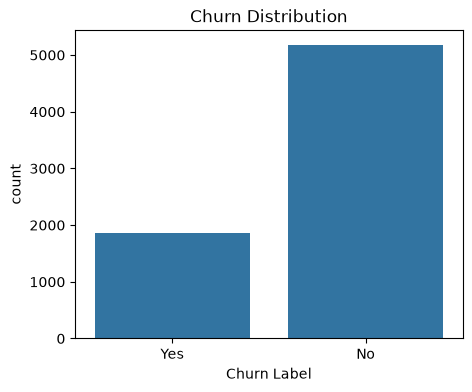

In [208]:
plt.figure(figsize=(5,4))
sns.countplot(data=df, x='Churn Label')
plt.title('Churn Distribution')
plt.show()

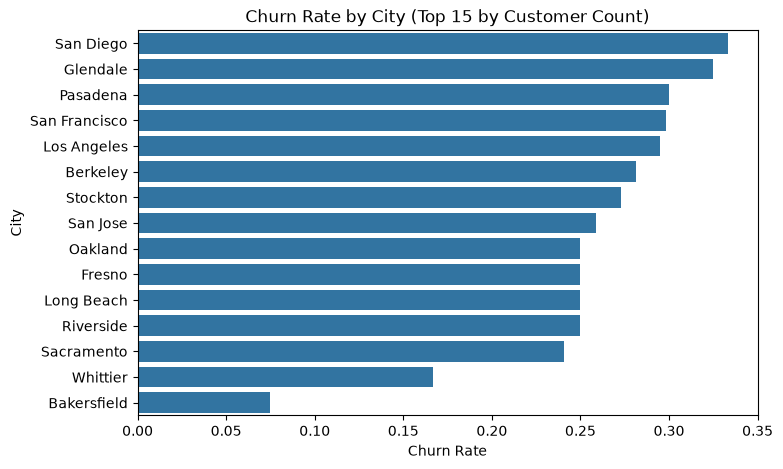

In [209]:
top_cities = df['City'].value_counts().head(15).index
city_churn = df[df['City'].isin(top_cities)].groupby('City')['Churn Value'].mean().sort_values(ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x=city_churn.values, y=city_churn.index)
plt.xlabel('Churn Rate')
plt.title('Churn Rate by City (Top 15 by Customer Count)')
plt.show()

In [210]:
# count the number of customers in each city and sort them in descending order
city_counts = df['City'].value_counts().sort_values(ascending=False)

print(city_counts.head(20))  # Displaying top 20 cities by customer count

City
Los Angeles       305
San Diego         150
San Jose          112
Sacramento        108
San Francisco     104
Fresno             64
Long Beach         60
Oakland            52
Stockton           44
Glendale           40
Bakersfield        40
Riverside          32
Berkeley           32
Whittier           30
Pasadena           30
San Bernardino     28
Irvine             28
Anaheim            28
Santa Barbara      28
Modesto            28
Name: count, dtype: int64


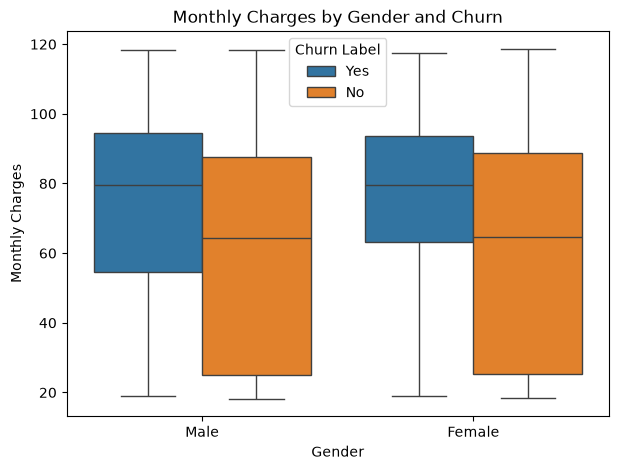

In [211]:
plt.figure(figsize=(7,5))
sns.boxplot(data=df, x='Gender', y='Monthly Charges', hue='Churn Label')
plt.title('Monthly Charges by Gender and Churn')
plt.show()

there is no difference in the monthly charges according to the gender, but the churning is clear to be higher with people with higher monlthly charges 

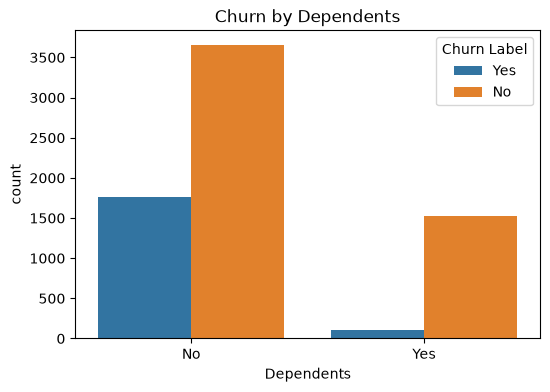

In [212]:
# dependets is categorical variable, we can use countplot to visualize the churn distribution across different dependent categories.
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Dependents', hue='Churn Label')
plt.title('Churn by Dependents')
plt.show()

it's clear that people with dependents have a much lower probability to churn , also dependent must be changed to bollean not kept as str

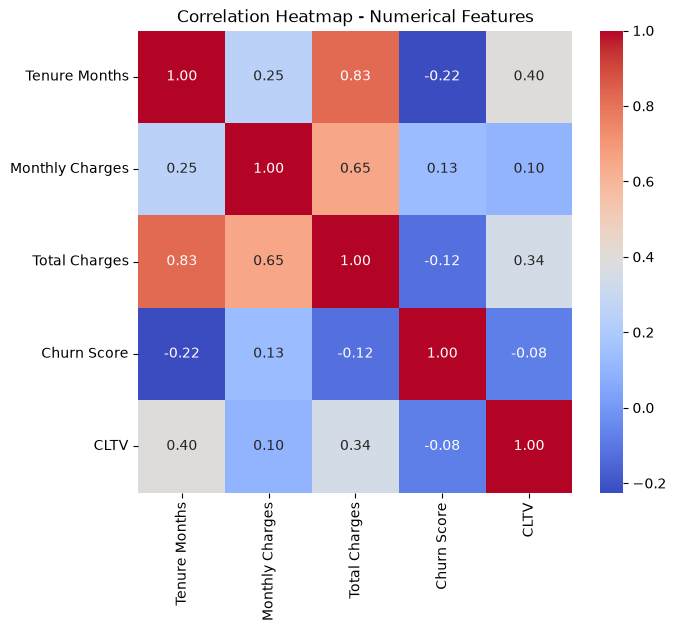

In [213]:
numeric_cols = ['Tenure Months', 'Monthly Charges', 'Total Charges', 'Churn Score', 'CLTV']
plt.figure(figsize=(7,6))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap - Numerical Features')
plt.show()
# expecting high correlation between Monthly Charges and Total Charges, and also between Churn Score and CLTV.
# since total charge is calculated based on monthly charges and tenure, we can expect a high correlation between these two features. 


there seems to be a strong relation between monthly charges, tenure charges and the Total charges. 
we should remove something to avoid high corelated variable in the regression 

In [214]:
df.groupby('Payment Method')['Churn Value'].mean().sort_values(ascending=False)

Payment Method
Electronic check             0.452854
Mailed check                 0.191067
Bank transfer (automatic)    0.167098
Credit card (automatic)      0.152431
Name: Churn Value, dtype: float64

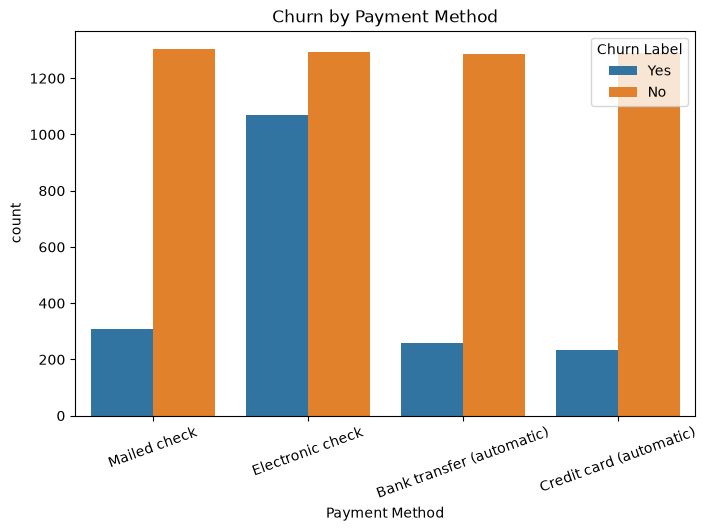

In [215]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='Payment Method', hue='Churn Label')
plt.xticks(rotation=20)
plt.title('Churn by Payment Method')
plt.show()

it's clear that the payment method effects the churning rate specially people who pay using electronic check 

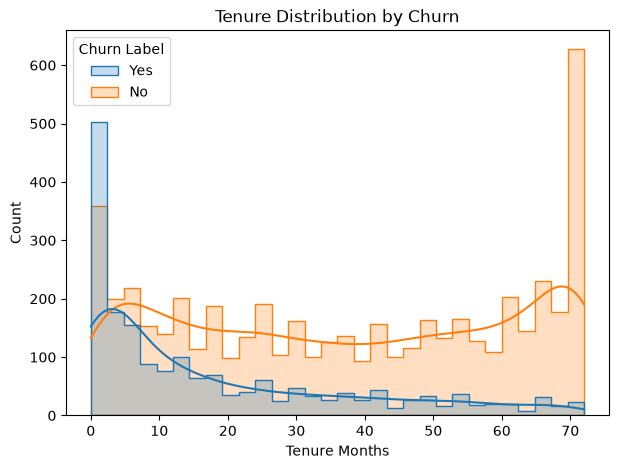

In [216]:
plt.figure(figsize=(7,5))
sns.histplot(data=df, x='Tenure Months', hue='Churn Label', kde=True, bins=30, element='step')
plt.title('Tenure Distribution by Churn')
plt.show()

it's clear that customers are more likely to churn in the first months at which they were provided the service and people who are there for relatively a long time don't tend to churn 

In [217]:
df.groupby('Contract')['Churn Value'].mean().sort_values(ascending=False)

Contract
Month-to-month    0.427097
One year          0.112695
Two year          0.028319
Name: Churn Value, dtype: float64

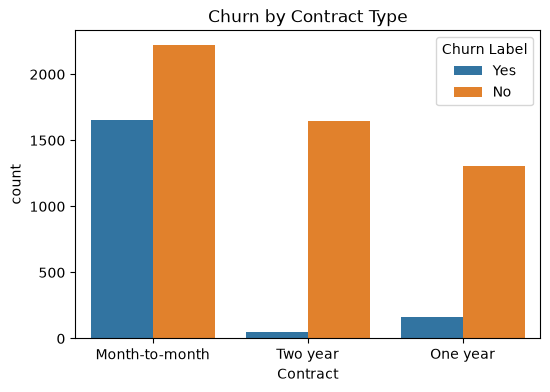

In [218]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Contract', hue='Churn Label')
plt.title('Churn by Contract Type')
plt.show()

people who pay month to month have a higher chance to churn 

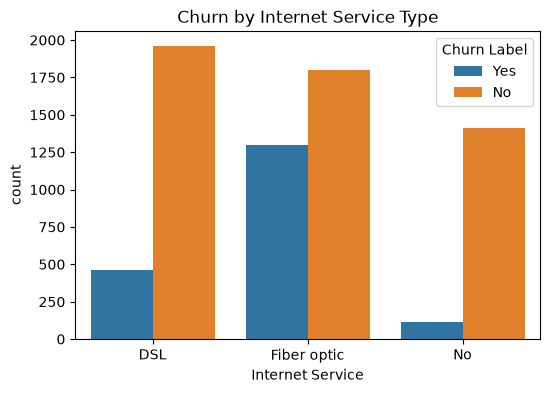

In [219]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Internet Service', hue='Churn Label')
plt.title('Churn by Internet Service Type')
plt.show()

people who have dsl or no internet service have much lower in churning 

In [220]:
df.groupby('Internet Service')['Churn Value'].mean().sort_values(ascending=False)

Internet Service
Fiber optic    0.418928
DSL            0.189591
No             0.074050
Name: Churn Value, dtype: float64

In [221]:
# just checking the top reasons people chrun 
print(df['Churn Reason'].value_counts().head(10))

Churn Reason
Attitude of support person                   192
Competitor offered higher download speeds    189
Competitor offered more data                 162
Don't know                                   154
Competitor made better offer                 140
Attitude of service provider                 135
Competitor had better devices                130
Network reliability                          103
Product dissatisfaction                      102
Price too high                                98
Name: count, dtype: int64


In [222]:
# I think that churn score is a good indicator of whether a customer will churn or not. 
# so it might be nedded to remove it since its a kind of target leakage.
print(df.groupby('Churn Label')['Churn Score'].mean())
print(df['Churn Score'].corr(df['Churn Value']))

Churn Label
No     50.098183
Yes    82.510433
Name: Churn Score, dtype: float64
0.6648970311816234


In [223]:
cols_to_drop = ['CustomerID', 'Count', 'Country', 'Lat Long', 'Latitude', 'Longitude', 'Zip Code', 'Churn Reason', 'Churn Score']
df = df.drop(columns=cols_to_drop)
df.shape

(7043, 24)

In [224]:
pd.set_option('display.max_columns', None)
df.head(2)

,State,City,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,CLTV
0,California,Los Angeles,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,3239
1,California,Los Angeles,Female,No,No,Yes,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,2701


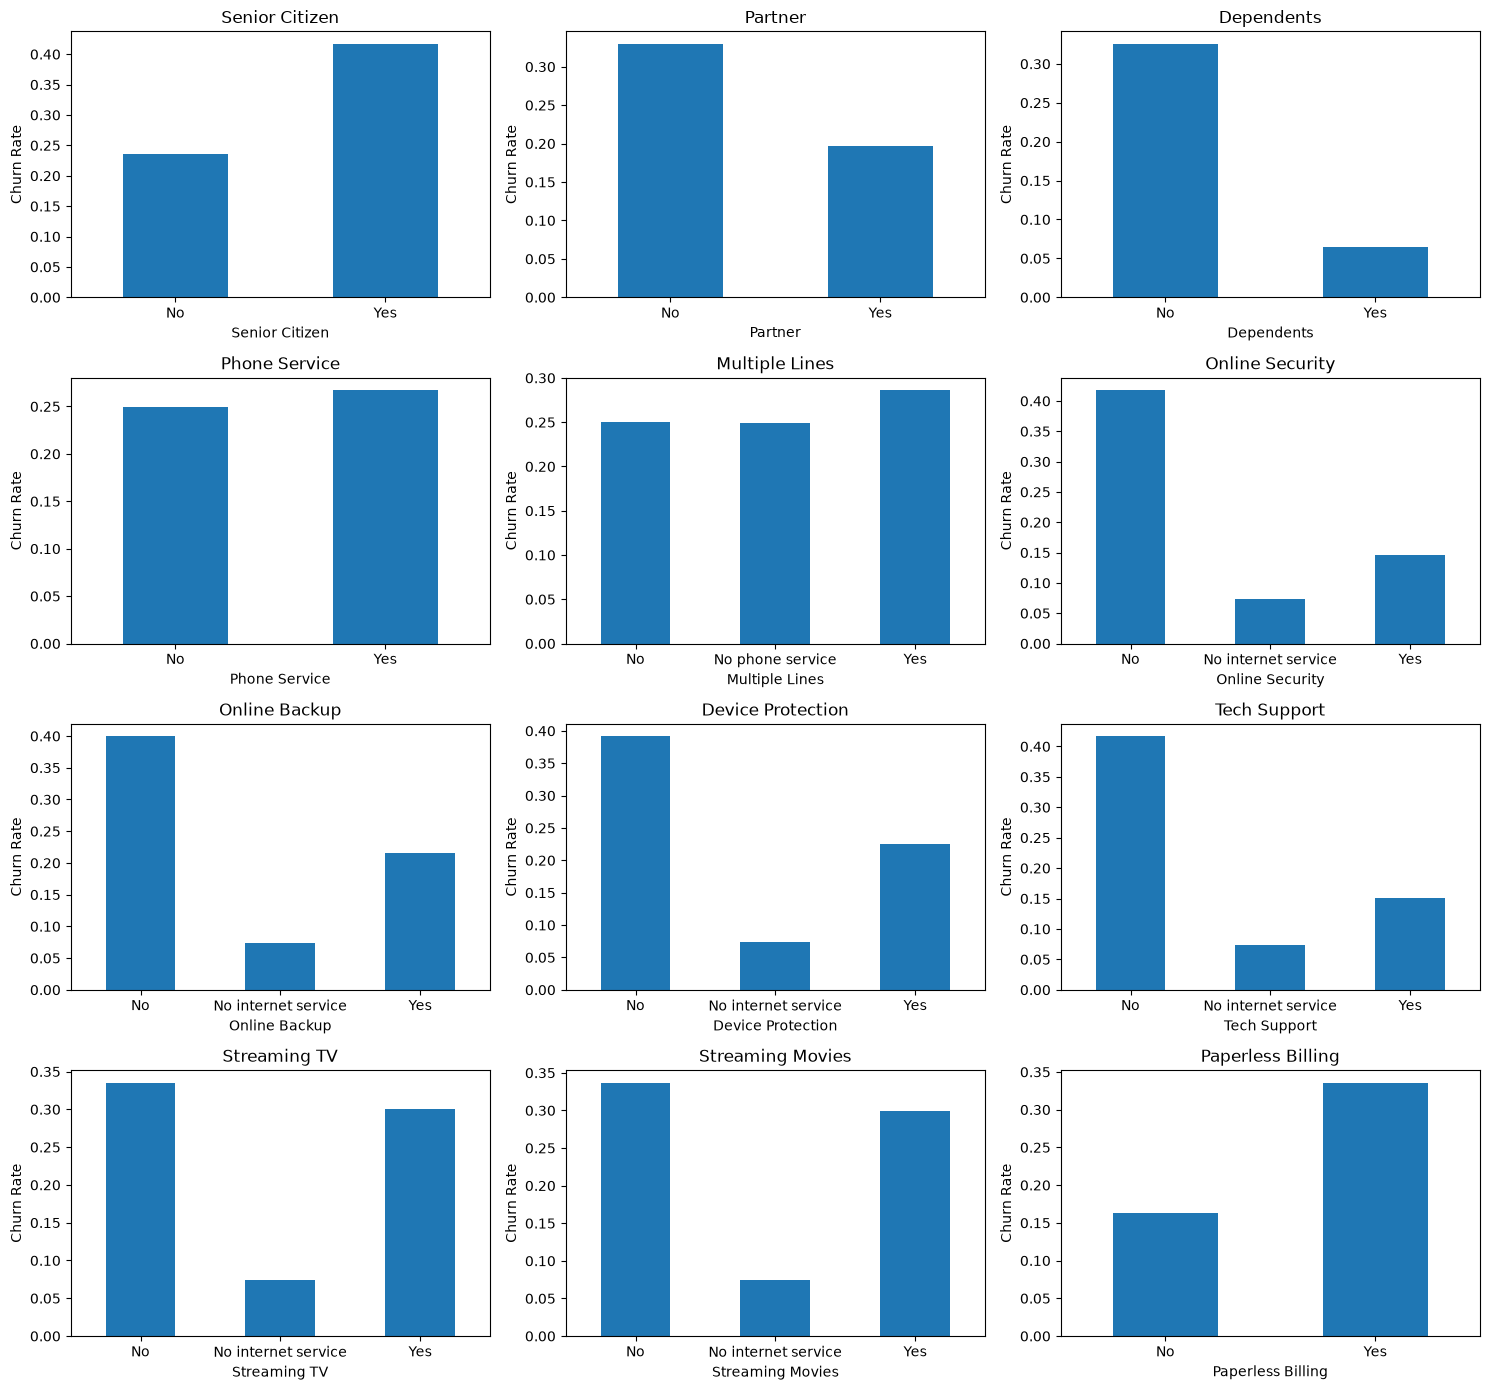

In [225]:
binary_like_cols = ['Senior Citizen', 'Partner', 'Dependents', 'Phone Service', 'Multiple Lines',
                     'Online Security', 'Online Backup', 'Device Protection', 'Tech Support',
                     'Streaming TV', 'Streaming Movies', 'Paperless Billing']

churn_rates = {col: df.groupby(col)['Churn Value'].mean() for col in binary_like_cols}

fig, axes = plt.subplots(4, 3, figsize=(15, 14))
axes = axes.flatten()
for i, col in enumerate(binary_like_cols):
    churn_rates[col].plot(kind='bar', ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_ylabel('Churn Rate')
    axes[i].tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

Online Security, Online Backup, Device Protection, Tech Support, Streaming TV, Streaming Movies are only for customer with internet service 

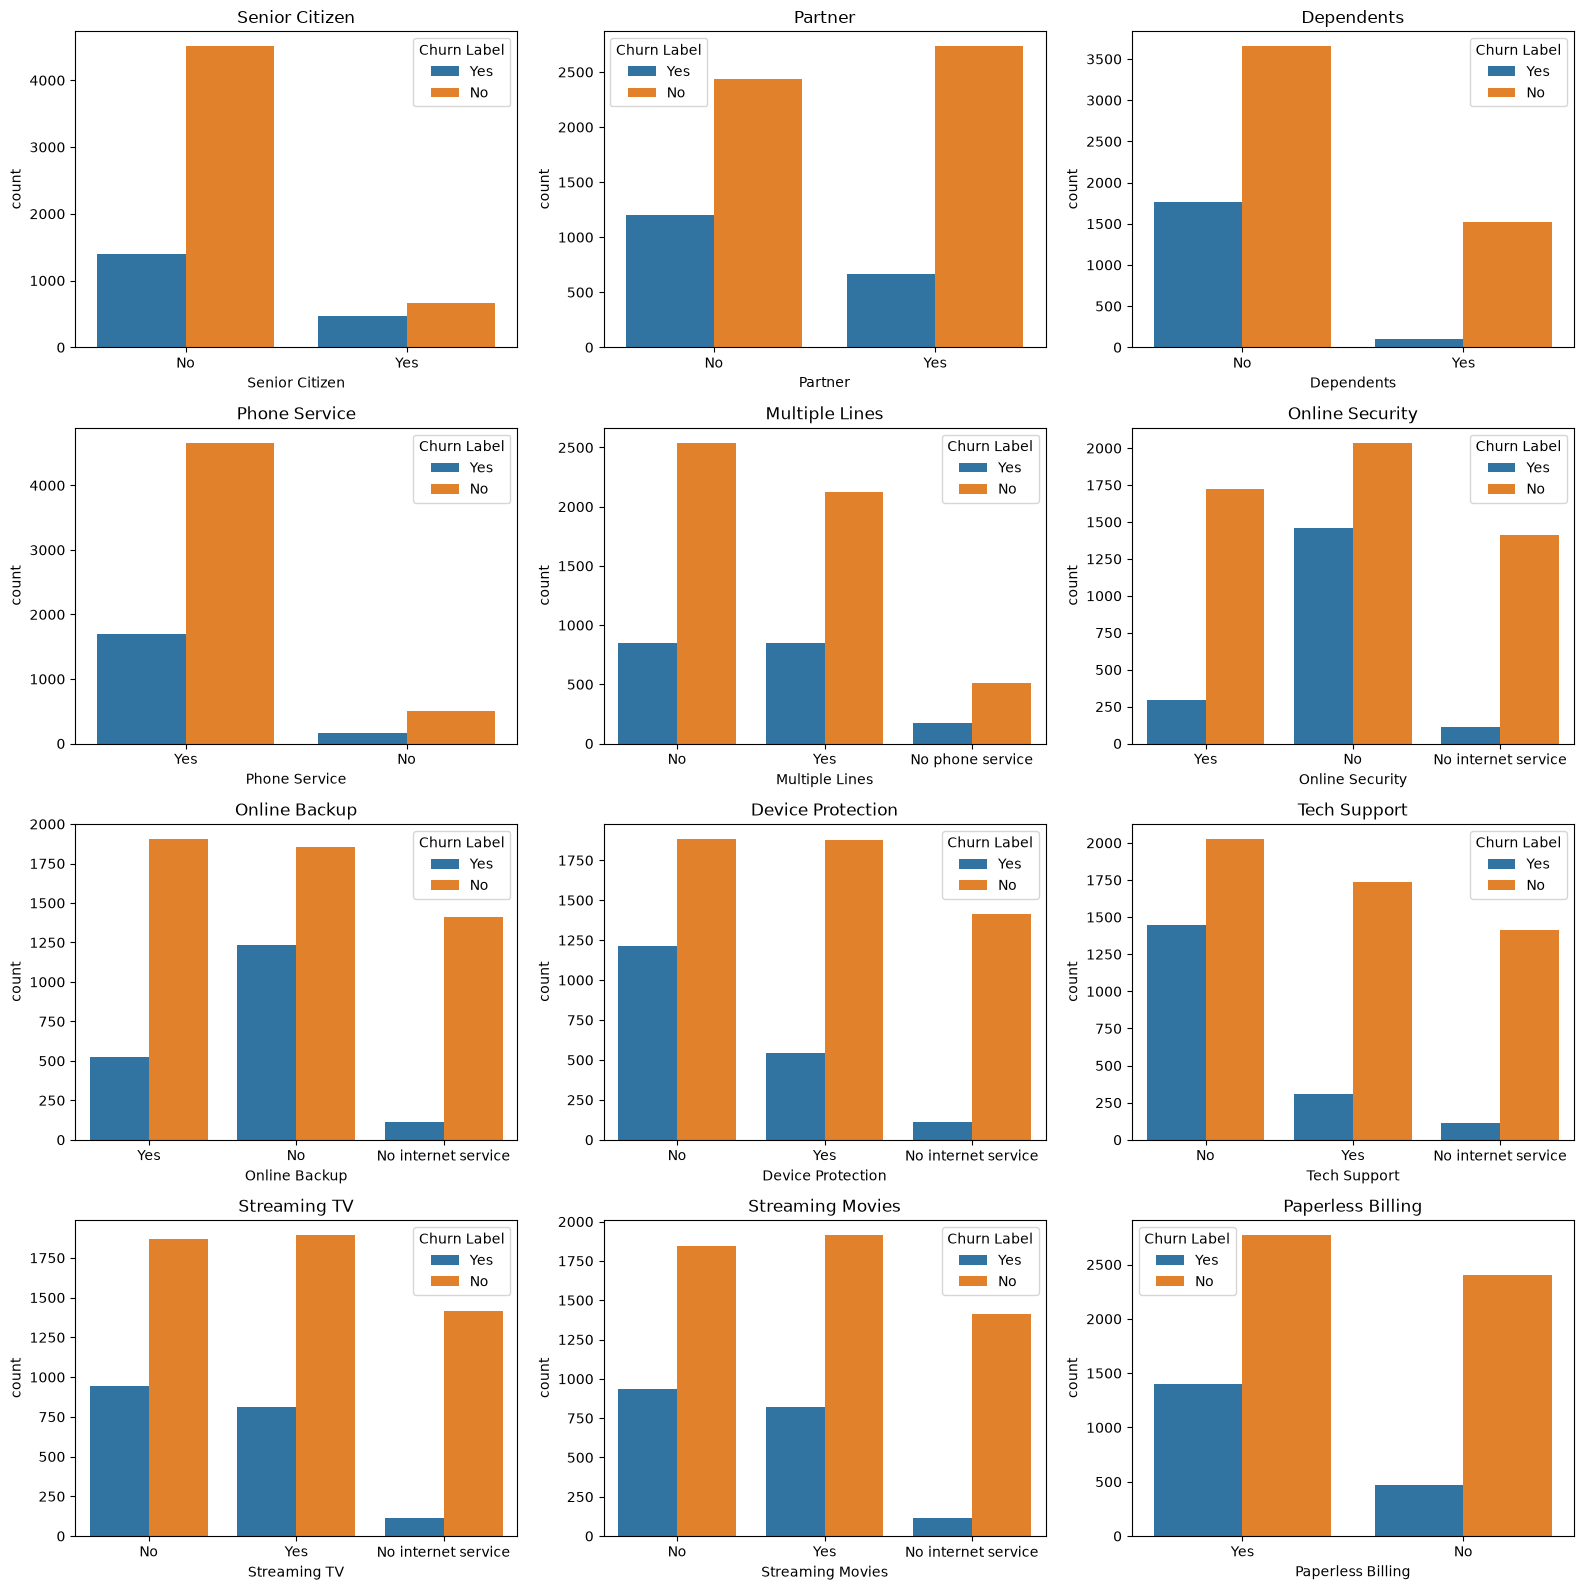

In [226]:
binary_like_cols = ['Senior Citizen', 'Partner', 'Dependents', 'Phone Service', 'Multiple Lines',
                     'Online Security', 'Online Backup', 'Device Protection', 'Tech Support',
                     'Streaming TV', 'Streaming Movies', 'Paperless Billing']

fig, axes = plt.subplots(4, 3, figsize=(16, 16))
axes = axes.flatten()
for i, col in enumerate(binary_like_cols):
    sns.countplot(data=df, x=col, hue='Churn Label', ax=axes[i])
    axes[i].set_title(col)
    axes[i].tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

In [227]:
df = df.drop(columns=['Gender', 'State'])
df.shape

(7043, 22)

In [228]:
service_cols = ['Multiple Lines', 'Online Security', 'Online Backup', 'Device Protection',
                 'Tech Support', 'Streaming TV', 'Streaming Movies']

for col in service_cols:
    df[col] = df[col].replace({'No internet service': 'No', 'No phone service': 'No'})
    df[col] = df[col].map({'Yes': 1, 'No': 0})

df[service_cols].nunique()

Multiple Lines       2
Online Security      2
Online Backup        2
Device Protection    2
Tech Support         2
Streaming TV         2
Streaming Movies     2
dtype: int64

In [229]:
binary_cols = ['Senior Citizen', 'Partner', 'Dependents', 'Phone Service', 'Paperless Billing']
for col in binary_cols:
    df[col] = df[col].map({'Yes': 1, 'No': 0})

df['Churn Value'] = df['Churn Value'].astype(int)
df[binary_cols + ['Churn Value']].dtypes

Senior Citizen       int64
Partner              int64
Dependents           int64
Phone Service        int64
Paperless Billing    int64
Churn Value          int64
dtype: object

In [230]:
df = pd.get_dummies(df, columns=['Internet Service', 'Contract', 'Payment Method'], drop_first=True)
df.shape

(7043, 26)

In [231]:
df = df.drop(columns=['City'])
df.shape

(7043, 25)

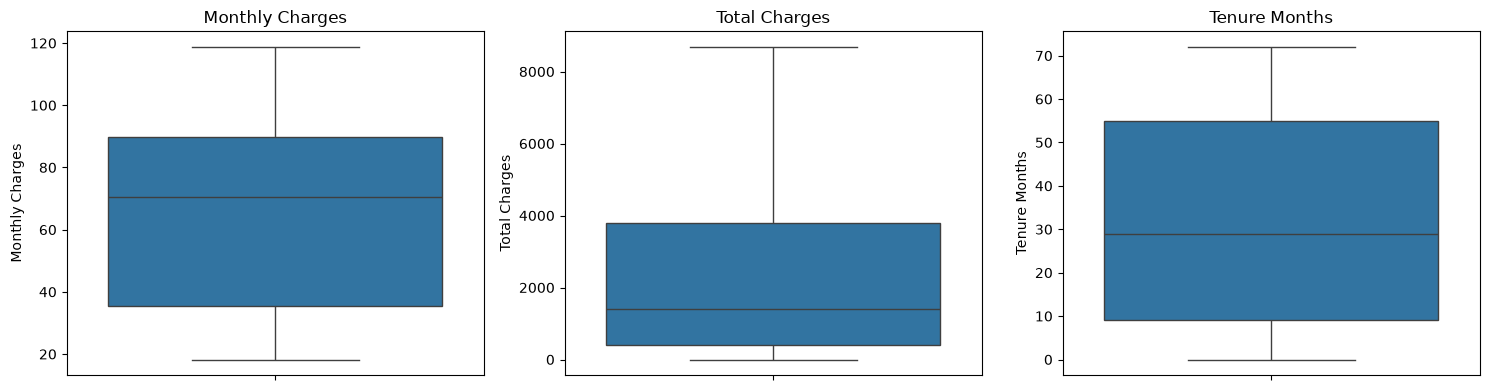

In [232]:
# checking for outliers in Monthly Charges, Total Charges, and Tenure Months using boxplots
fig, axes = plt.subplots(1, 3, figsize=(15,4))
for ax, col in zip(axes, ['Monthly Charges', 'Total Charges', 'Tenure Months']):
    sns.boxplot(y=df[col], ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

In [233]:
df.to_csv('../data/telco_cleaned.csv', index=False)

We started with 7,043 customers and 33 columns. After exploring the data, we removed columns that were either identifiers (CustomerID), constant across all rows (Count, Country, State), redundant location data (Zip Code, Lat Long, Latitude, Longitude), or would leak the answer to the model (Churn Score, Churn Reason both directly reflect whether a customer already churned).

The EDA showed several clear churn drivers: customers on month-to-month contracts, paying by electronic check, with fiber optic internet, high monthly charges, no dependents, and low tenure (especially the first few months) are far more likely to churn. Customers without add-on services like Online Security or Tech Support also churn more, likely because they're less "locked in" to the platform.

We also found and fixed one data quality issue (11 blank Total Charges values, all belonging to brand-new customers with 0 tenure, filled with 0) and one multicollinearity issue (Total Charges is just Tenure × Monthly Charges, so we're keeping the two separate components instead).

All remaining categorical columns were encoded into numeric form (binary Yes/No fields mapped to 0/1, multi-category fields one-hot encoded), and the redundant Churn Label text column was dropped, keeping Churn Value as the single numeric target. Scaling and class-imbalance handling are deferred to the modeling notebooks, done after the train/test split to avoid data leakage.